# Access the analysis ready CAMS global reanalysis (EAC4) monthly data

This notebook provides an example of how to open the cams-global-reanalysis-eac4-monthly Zarr store using xarray.
You will need to insert your CDS API key where indicated in the following code cell (available on [your profile page](https://ads.atmosphere.copernicus.eu/profile)).
For more information on using the Data Store Analysis Ready Datasets, please see the [user documentation pages](https://cds.climate.copernicus.eu/datasets/how-to-use-the-dss-arco-dataset).

In [1]:
import os
cdsapi_key = "<INSERT-CDS-API-KEY-HERE>"

# The following attempts to find the CDS API key in your environment.
if cdsapi_key == "<INSERT-CDS-API-KEY-HERE>":
    cdsapi_key = None
if cdsapi_key is None:
    cdsapi_key = os.getenv("CDSAPI_KEY")
if cdsapi_key is None and os.path.exists(os.path.expanduser("~/.cdsapirc")):
    with open(os.path.expanduser("~/.cdsapirc"), "r") as f:
        for line in f:
            if line.startswith("key:"):
                cdsapi_key = line.split(":")[1].strip()
                break
if cdsapi_key is None:
    raise ValueError("CDS API key not found. Please set the CDSAPI_KEY environment variable or create a ~/.cdsapirc file.")


## Plug and play access

The code below provides a simple plug and play example of how to use the Zarr Store for light-weight access.

In [2]:
import xarray as xr

# Geo-chunked monthly single levels data (optimised for time-series at a single location)
geochunked_sfc_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-010/arco/cams_global_reanalysis_eac4_monthly/sfc/geoChunked.zarr"

# Time-chunked monthly single levels data (optimised for global map at a single time step)
timechunked_sfc_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-010/arco/cams_global_reanalysis_eac4_monthly/sfc/timeChunked.zarr"

# Geo-chunked monthly pressure levels data (optimised for time-series at a single location)
geochunked_pl_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-010/arco/cams_global_reanalysis_eac4_monthly/pl/geoChunked.zarr"

# Time-chunked monthly pressure levels data (optimised for global map at a single time step)
timechunked_pl_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-010/arco/cams_global_reanalysis_eac4_monthly/pl/timeChunked.zarr"


# Open the zarr store with xarray, users must insert their API key where indicated.
ds = xr.open_zarr(
    geochunked_sfc_url,
    consolidated=True,
     storage_options = {
        "headers": {"Authorization": f"Bearer {cdsapi_key}"}
    }
)
 
# Inspect the variables
ds

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 272, latitude: 241, longitude: 480)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2003-01-01 2003-02-01 ... 2025-08-01
  * latitude   (latitude) float64 2kB -90.0 -89.25 -88.5 ... 88.5 89.25 90.0
  * longitude  (longitude) float64 4kB -180.0 -179.2 -178.5 ... 178.5 179.2
Data variables: (12/13)
    aod550     (time, latitude, longitude) float32 126MB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    bcaod550   (time, latitude, longitude) float32 126MB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    duaod550   (time, latitude, longitude) float32 126MB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    gtco3      (time, latitude, longitude) float32 126MB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    omaod550   (time, latitude, longitude) float32 126MB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    pm10       (time, latitude, longitude) float32 126MB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    ...         ...
    ssaod550   (time, latitude, longitude) float32 126MB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    suaod550   (time, latitude, longitude) float32 126MB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    tcco       (time, latitude, longitude) float32 126MB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    tchcho     (time, latitude, longitude) float32 126MB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    tcno2      (time, latitude, longitude) float32 126MB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    tcso2      (time, latitude, longitude) float32 126MB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-03-20T13:56 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

Extract a point and plot a time-series using earthkit-plots.

/var/folders/l2/529q7bzs665bnrn7_wjx1nsr0000gn/T/ipykernel_61440/1522264277.py:9: UserWarning: TimeSeries is an experimental new feature in earthkit-plots. We welcome feedback and bug reports on GitHub issues: https://github.com/ecmwf/earthkit-plots/issues
  chart = ekp.TimeSeries()
/Users/edwardcomyn-platt/Work/Git_Repositories/ecmwf-projects/dss-jupyterhub-notebooks/dss-notebooks/.venv/lib/python3.12/site-packages/earthkit/plots/components/subplots.py:1213: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax.legend(*args, **kwargs)


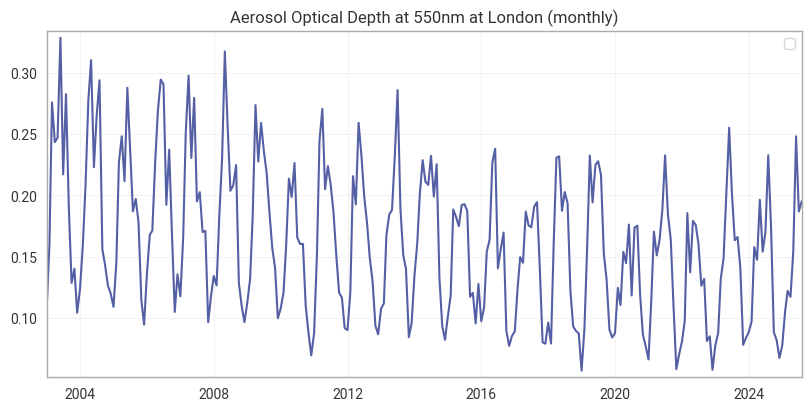

In [3]:
from earthkit import plots as ekp

# Select variable to plot
variable_name = "aod550"
plot_data = ds[variable_name].sel(
    latitude=51.5, longitude=-0.1, method="nearest"
)

chart = ekp.TimeSeries()

chart.line(plot_data)

chart.title("Aerosol Optical Depth at 550nm at London (monthly)")
chart.legend()

chart.show()

## Advanced usage

If your workflow requires access to larger amounts of data, it is recommended that you include a retry mechanism.
This is not provided in the current default zarr engine for xarray, instead we can define a custom "`store`" which is
used when connecting to the remote zarr data.

In [4]:
!pip install -q obstore
import xarray as xr
from obstore.store import HTTPStore
from zarr.storage import ObjectStore

# Geo-chunked monthly single levels data (optimised for time-series at a single location)
geochunked_sfc_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-010/arco/cams_global_reanalysis_eac4_monthly/sfc/geoChunked.zarr"

# Time-chunked monthly single levels data (optimised for global map at a single time step)
timechunked_sfc_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-010/arco/cams_global_reanalysis_eac4_monthly/sfc/timeChunked.zarr"

# Geo-chunked monthly pressure levels data (optimised for time-series at a single location)
geochunked_pl_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-010/arco/cams_global_reanalysis_eac4_monthly/pl/geoChunked.zarr"

# Time-chunked monthly pressure levels data (optimised for global map at a single time step)
timechunked_pl_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-010/arco/cams_global_reanalysis_eac4_monthly/pl/timeChunked.zarr"


# Use obstore's HTTPStore to create a store with retry configuration,
# and then wrap it in a zarr ObjectStore to read with xarray.
# See https://github.com/developmentseed/obstore/blob/main/obstore/python/obstore/_store/_retry.pyi
# for more details on the retry configuration options.
http_store = HTTPStore(
    geochunked_sfc_url,
    client_options={
        "default_headers": {"Authorization": f"Bearer {cdsapi_key}"},
    },
)
store = ObjectStore(http_store, read_only=True)
ds = xr.open_zarr(store)
ds


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


<xarray.Dataset> Size: 2GB
Dimensions:    (time: 272, latitude: 241, longitude: 480)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2003-01-01 2003-02-01 ... 2025-08-01
  * latitude   (latitude) float64 2kB -90.0 -89.25 -88.5 ... 88.5 89.25 90.0
  * longitude  (longitude) float64 4kB -180.0 -179.2 -178.5 ... 178.5 179.2
Data variables: (12/13)
    aod550     (time, latitude, longitude) float32 126MB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    bcaod550   (time, latitude, longitude) float32 126MB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    duaod550   (time, latitude, longitude) float32 126MB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    gtco3      (time, latitude, longitude) float32 126MB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    omaod550   (time, latitude, longitude) float32 126MB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    pm10       (time, latitude, longitude) float32 126MB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    ...         ...
    ssaod550   (time, latitude, longitude) float32 126MB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    suaod550   (time, latitude, longitude) float32 126MB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    tcco       (time, latitude, longitude) float32 126MB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    tchcho     (time, latitude, longitude) float32 126MB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    tcno2      (time, latitude, longitude) float32 126MB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
    tcso2      (time, latitude, longitude) float32 126MB dask.array<chunksize=(264, 64, 64), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-03-20T13:56 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

The result is the same as the previous example, this just provides a more robust connection, preventing your
workflow crashing due to temporary network issues.